<a href="https://colab.research.google.com/github/veekshavkamath-blip/Task0.4.repo/blob/main/MRMCARPRICESTASK.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [412]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [413]:
price=pd.read_csv('CarPrice_Assignment.csv')

In [414]:
price.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   car_ID            205 non-null    int64  
 1   symboling         205 non-null    int64  
 2   CarName           205 non-null    object 
 3   fueltype          205 non-null    object 
 4   aspiration        205 non-null    object 
 5   doornumber        205 non-null    object 
 6   carbody           205 non-null    object 
 7   drivewheel        205 non-null    object 
 8   enginelocation    205 non-null    object 
 9   wheelbase         205 non-null    float64
 10  carlength         205 non-null    float64
 11  carwidth          205 non-null    float64
 12  carheight         205 non-null    float64
 13  curbweight        205 non-null    int64  
 14  enginetype        205 non-null    object 
 15  cylindernumber    205 non-null    object 
 16  enginesize        205 non-null    int64  
 1

In [415]:
print(price.isnull().sum())

car_ID              0
symboling           0
CarName             0
fueltype            0
aspiration          0
doornumber          0
carbody             0
drivewheel          0
enginelocation      0
wheelbase           0
carlength           0
carwidth            0
carheight           0
curbweight          0
enginetype          0
cylindernumber      0
enginesize          0
fuelsystem          0
boreratio           0
stroke              0
compressionratio    0
horsepower          0
peakrpm             0
citympg             0
highwaympg          0
price               0
dtype: int64


In [416]:
price.head()

,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,1,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0
1,2,3,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0
2,3,1,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0
3,4,2,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0
4,5,2,audi 100ls,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0


In [417]:
print(price.shape)

(205, 26)


In [418]:
price = pd.read_csv("CarPrice_Assignment.csv")
price = price.drop(columns="car_ID")
price["CarName"] = price["CarName"].str.split().str[0].str.lower()
data = pd.get_dummies(price, dtype=float)

In [419]:
data = pd.get_dummies(price, dtype=float)

In [420]:
y=data["price"].values
x=data.drop(columns="price").values.astype(float)

In [421]:
split=int(0.8*len(x))
idx=np.arange(len(x))
rng=np.random.default_rng(42)
rng.shuffle(idx)
train_idx,test_idx=idx[:split],idx[split:]
x_train,x_test=x[train_idx],x[test_idx]
y_train,y_test=y[train_idx],y[test_idx]

In [422]:
X = x_train.mean(axis=0)
sigma= x_train.std(axis=0)
sigma[sigma == 0] = 1
x_train = (x_train - X) / sigma
x_test = (x_test - X) / sigma


In [423]:
x_train = np.c_[np.ones(len(x_train)), x_train]
x_test = np.c_[np.ones(len(x_test)), x_test]
print(x_train.shape, x_test.shape)


(164, 80) (41, 80)


In [424]:
def gradient_descent(X, y, alpha=0.09, iters=300,lam=10):
    m, n = X.shape
    w = np.zeros(n)
    costs = []
    for _ in range(iters):
        err = X @ w - y
        reg = lam * w; reg[0] = 0
        w -= alpha * (X.T @ err + reg) / m
        costs.append((err @ err) / (2 * m))
    return w, costs

w, costs = gradient_descent(x_train, y_train)

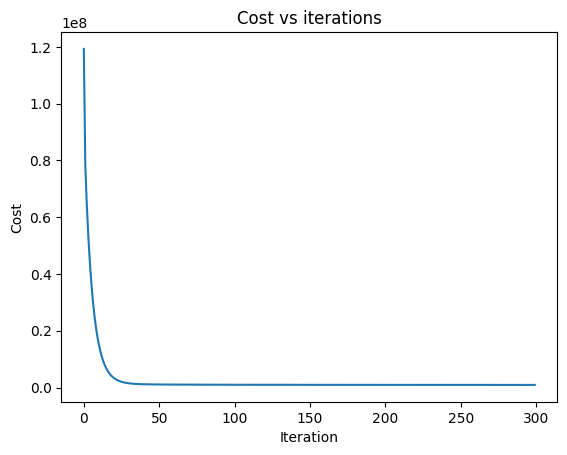

In [425]:
plt.plot(costs)
plt.xlabel("Iteration"); plt.ylabel("Cost"); plt.title("Cost vs iterations")
plt.show()


In [426]:
def rmse(y_true, y_pred):
    return np.sqrt(np.mean((y_true - y_pred) ** 2))

def r2(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - y_true.mean()) ** 2)
    return 1 - ss_res / ss_tot

def mae(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred))

pred_train = x_train @ w
pred_test = x_test @ w
print("Train RMSE:", rmse(y_train, pred_train), " R2:", r2(y_train, pred_train),"Train  MAE:", mae(y_train, pred_train))
print("Test  RMSE:", rmse(y_test, pred_test), " R2:", r2(y_test, pred_test),"Test  MAE:", mae(y_test, pred_test))


Train RMSE: 1359.056967032747  R2: 0.9701073967666891 Train  MAE: 951.7459196436508
Test  RMSE: 2890.4038967433175  R2: 0.8813078229115219 Test  MAE: 1898.1992501966356


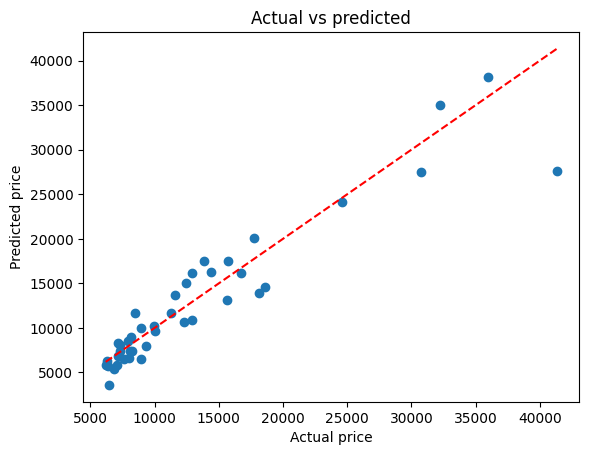

In [427]:
plt.scatter(y_test, pred_test)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--")
plt.xlabel("Actual price"); plt.ylabel("Predicted price"); plt.title("Actual vs predicted")
plt.show()